# DL072 独立研究项目与审查

本Notebook从零训练五方法×三个种子的完整项目。全部数据离线生成，结果另存notebook_outputs，图从本次结果生成。

In [1]:
from pathlib import Path
import json, numpy as np, torch
import matplotlib.pyplot as plt
from experiment import run, network, predict, metrics, VARIANTS, DOMAINS
torch.set_num_threads(1)
print("PyTorch",torch.__version__,"CPU one thread")
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    buffer=BytesIO()
    fig.savefig(buffer,format="png",dpi=140,bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

PyTorch 2.14.1+cpu CPU one thread


## 1 读取预定研究协议
主指标与辅助指标在观察测试结果前固定。

In [2]:
plan=json.loads(Path("research_plan.json").read_text())
print(plan["question"])
print(plan["primary"])
print(plan["variants"],plan["seeds"])

Can label-independent training corner randomization reduce shortcut-reversal classification error?
mean full-coverage error on paired shortcut-flip test domain
['linear', 'erm', 'random_corner', 'wrong_corner', 'mask_corner'] [11, 23, 37]


## 2 真实训练15个模型
没有读取已有权重跳过训练。

In [3]:
result=run("notebook_outputs")
print("Models",len(result["runs"]),"updates",result["budget"]["optimizer_updates"])
for name,a in result["aggregate"].items():
    print(name,{domain:round(v["mean_error"],6) for domain,v in a["domains"].items()})

Models 15 updates 2400
linear {'id': 0.057778, 'flip': 0.72, 'blank': 0.273333, 'core_noise': 0.114444}
erm {'id': 0.057778, 'flip': 0.682778, 'blank': 0.244444, 'core_noise': 0.124444}
random_corner {'id': 0.182222, 'flip': 0.182222, 'blank': 0.182222, 'core_noise': 0.300556}
wrong_corner {'id': 0.045556, 'flip': 0.659444, 'blank': 0.230556, 'core_noise': 0.125}
mask_corner {'id': 0.182222, 'flip': 0.182222, 'blank': 0.182222, 'core_noise': 0.297222}


## 3 检查配对输入
固定一个样本，角标变动但中心数据不变。

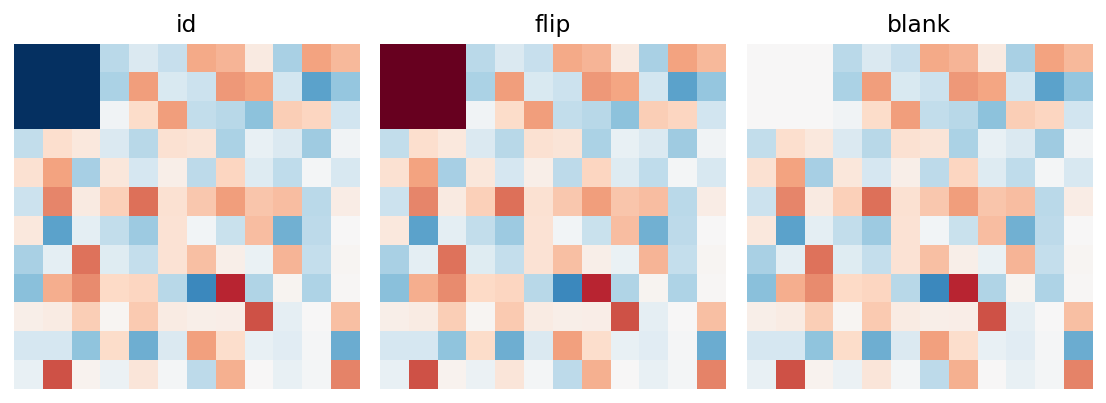

In [4]:
root=Path("notebook_outputs");data=np.load(root/"data.npz")
fig,axes=plt.subplots(1,3,figsize=(8,3))
for ax,name in zip(axes,["id","flip","blank"]):
    ax.imshow(data[name+"_x"][0,0],cmap="RdBu_r",vmin=-2.2,vmax=2.2);ax.set_title(name);ax.axis("off")
fig.tight_layout();show(fig)

## 4 重载所有checkpoint并复核预测
方法预处理必须与训练定义配套。

In [5]:
saved=np.load(root/"predictions.npz")
for path in sorted(root.glob("*_seed*.pt")):
    ck=torch.load(path,weights_only=True);m=network(ck["variant"]);m.load_state_dict(ck["state_dict"])
    p=predict(m,data["flip_x"],ck["variant"])
    np.testing.assert_array_equal(p,saved[f"{ck['variant']}_seed{ck['seed']}_flip"])
print("15 checkpoint predictions match exactly")

15 checkpoint predictions match exactly


## 5 全方法四域均值和标准差
误差条是三个固定数据训练种子的样本标准差，不是总体风险置信区间。

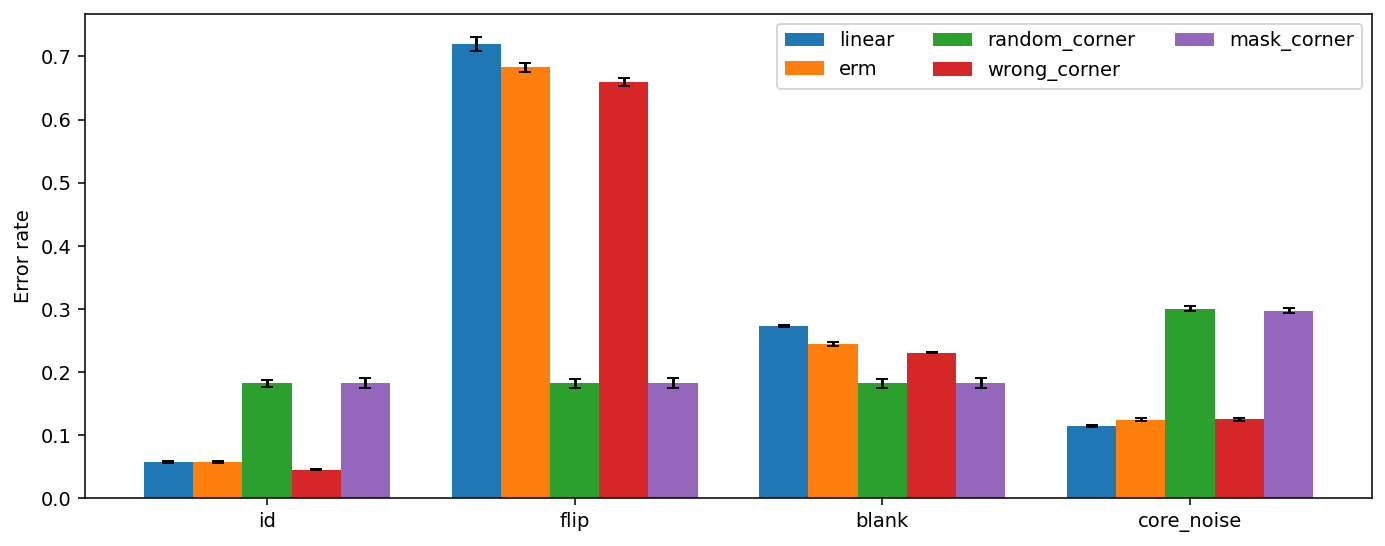

In [6]:
fig,ax=plt.subplots(figsize=(10,4))
x=np.arange(len(DOMAINS));width=.16
for j,v in enumerate(VARIANTS):
    a=result["aggregate"][v]["domains"]
    ax.bar(x+(j-2)*width,[a[d]["mean_error"] for d in DOMAINS],width,yerr=[a[d]["sd_error"] for d in DOMAINS],capsize=3,label=v)
ax.set_xticks(x,DOMAINS);ax.set_ylabel("Error rate");ax.legend(ncol=3);fig.tight_layout();show(fig)

## 6 配对改善与原域代价
先同种子相减，再统计差值；不要选最佳种子。

In [7]:
delta=np.array(result["paired_difference"]["by_seed"])
print("Paired differences",delta,"mean",delta.mean(),"sample SD",delta.std(ddof=1))
a=result["aggregate"]
print("ID error cost",a["random_corner"]["domains"]["id"]["mean_error"]-a["erm"]["domains"]["id"]["mean_error"])
print("Budget",result["budget"])

Paired differences [0.50833333 0.485      0.50833333] mean 0.5005555555555556 sample SD 0.013471506281091259
ID error cost 0.12444444444444441
Budget {'models': 15, 'optimizer_updates': 2400, 'training_examples_processed': 1920000, 'sum_training_seconds': 1.7228416719990491, 'training_tensor_bytes': 467200, 'checkpoint_total_bytes': 268653, 'timing_scope': 'per-model optimization only; process total includes data, evaluation, saving; installation and document build excluded'}


## 7 确认本次重跑与固定证据一致
计时随环境负载变化，故不比较计时。

In [8]:
ref=json.loads(Path("outputs/results.json").read_text())
for a,b in zip(result["runs"],ref["runs"]):
    if a["variant"]!=b["variant"] or a["seed"]!=b["seed"]: raise RuntimeError("Run order changed")
    np.testing.assert_allclose(a["losses"],b["losses"],rtol=1e-6,atol=1e-8)
    for domain in DOMAINS:
        if a["domains"][domain]["errors"]!=b["domains"][domain]["errors"]: raise RuntimeError("Error counts changed")
print("All deterministic loss trajectories and error counts match")

All deterministic loss trajectories and error counts match


## 最终审查
随机化在已知捷径反转域改善，但原域与核心噪声域代价明显，简单遮挡表现相近。真实图像、未知位置、更多数据划分与风险控制仍待验证。本项目不提出发表价值或方法创新声明。